# Data Preparation Pipeline — Declarative (Zero-Code)

This notebook demonstrates the **new** `ds_engine.preparation` module. 
Following DSEngine's **Zero-Code** philosophy, the entire pipeline is declared in a single YAML file.  
No custom Python code is needed to impute, scale, encode, or run statistical tests.

---

## What this pipeline does

| Step | Block | Action |
|------|-------|--------|
| 1 | `impute` | Fill missing values (median) |
| 2 | `scale` | Standard-scale numeric columns |
| 3 | `encode` | Label-encode `group` (A/B/C → 0/1/2) |
| 4 | `encode` | Label-encode `education` |
| 5 | `summary` | Summary stats on the transformed data |
| 6 | `hypothesis` | One-way ANOVA + Eta² effect size + Tukey HSD |
| 7 | `relationships` | Pearson correlations between all column pairs |

---


## 1 — The YAML Configuration

Everything is declared here. No Python needed.

In [1]:
with open('../configs/06_data_prep.yml', 'r') as f:
    print(f.read())

06_data_preparation_demo:
  data:
    source: "examples/datasets/prep_demo.csv"

  output:
    path: "examples/outputs/"
    format: ["json", "html"]

  steps:
    # --- Step 1: Handle Missing Values ---
    # Fill any nulls using the median of each column
    - name: "fill_missing_values"
      type: "impute"
      columns: ["age", "income"]
      params:
        method: "median"

    # --- Step 2: Normalize Numeric Features ---
    # Standard scale so all numeric columns are on the same scale
    - name: "standardize_features"
      type: "scale"
      columns: ["age", "income", "score"]
      params:
        method: "standard"

    # --- Step 3: Encode Categorical Columns ---
    # One-hot encode the 'group' column (A/B/C -> 0/1/2 for label, or dummies for onehot)
    - name: "encode_group"
      type: "encode"
      columns: ["group"]
      params:
        method: "label"

    # Label-encode the 'education' column (ordinal)
    - name: "encode_education"
      type: "encode"
      

## 2 — Peek at the Raw Dataset

The demo dataset (`prep_demo.csv`) has 20 rows and 5 columns, with 2 intentional missing values.

In [2]:
import sys, os
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

df_raw = pd.read_csv('../examples/datasets/prep_demo.csv')
print('Shape:', df_raw.shape)
print('\nMissing values:')
print(df_raw.isnull().sum())
print()
df_raw

Shape: (20, 5)

Missing values:
age          1
income       2
group        0
score        0
education    0
dtype: int64



,age,income,group,score,education
0,25.0,50000.0,A,10,High School
1,NaN,60000.0,A,12,Bachelor
2,30.0,NaN,B,11,Master
3,35.0,80000.0,B,15,Bachelor
4,40.0,90000.0,C,14,PhD
5,22.0,45000.0,A,9,High School
6,28.0,55000.0,B,13,Bachelor
7,33.0,75000.0,C,16,Master
8,38.0,85000.0,A,11,PhD
9,45.0,95000.0,B,14,Master


## 3 — Run the Pipeline

One call. That's it.

Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.


+--------------------------------------------------------------+
|  DSEngine  |  Experiment: 06_data_preparation_demo      |
|  Config  : ../configs/06_data_prep.yml                     |
|  Started : 2026-03-25 07:00:00                             |
+--------------------------------------------------------------+
> Loading data...
  Source  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\datasets\prep_demo.csv
  Shape   : 20 rows x 5 columns
  Columns : age, income, group, score, education
> Pre-flight inspection...
  v  No fatal issues.
  !  1 warning(s) — check before interpreting results:
     [1] Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.
> Running steps (7 total):
  [1/7] fill_missing_values (impute        ) ... done  (0.00s)
  [2/7] standardize_features (scale         ) ... done  (0.00s)
  [3/7] encode_group     (encode        ) ... done  (0.00s)
  [4/7] encode_education (encode        ) ... 

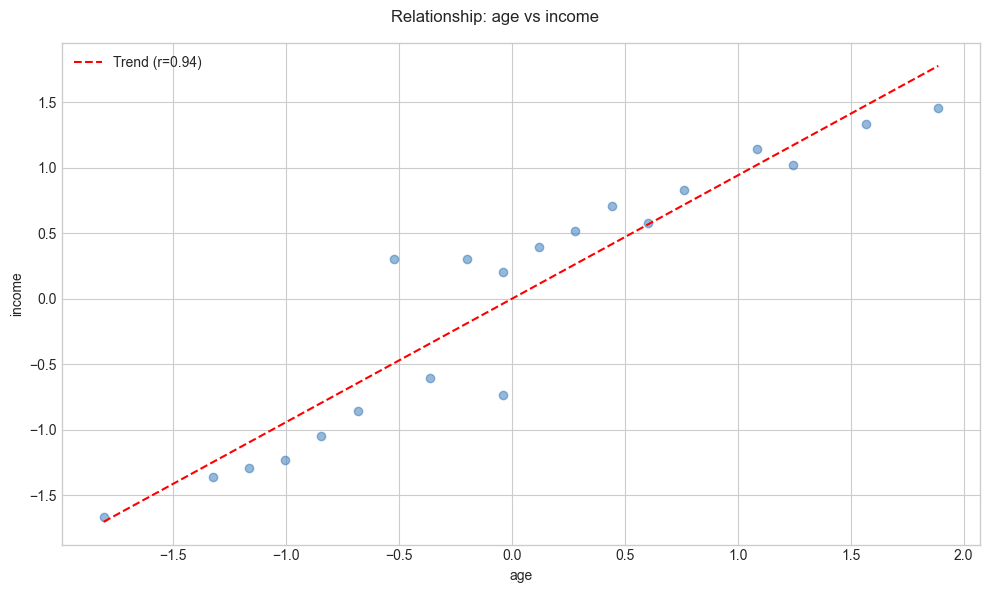

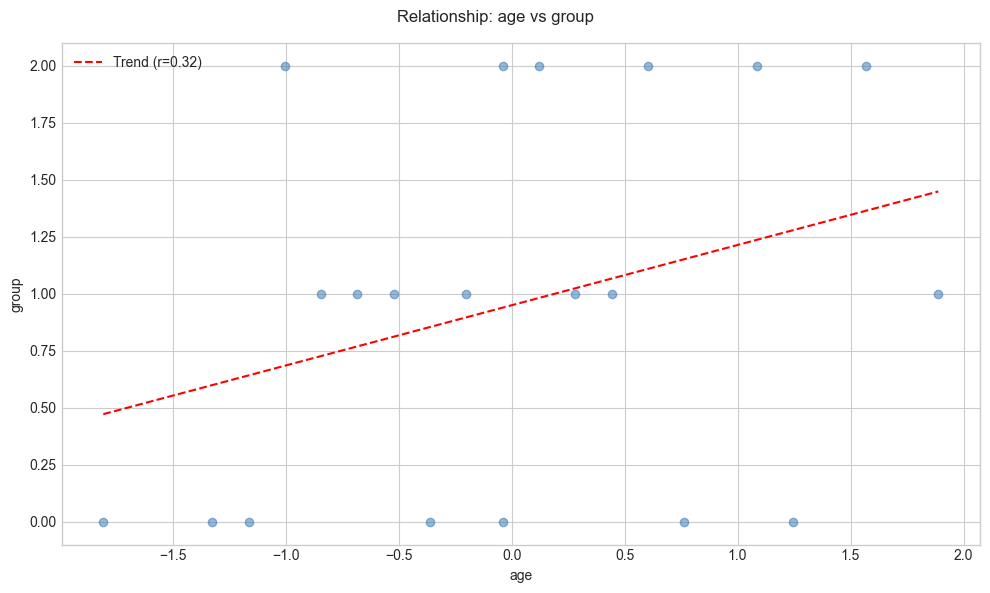

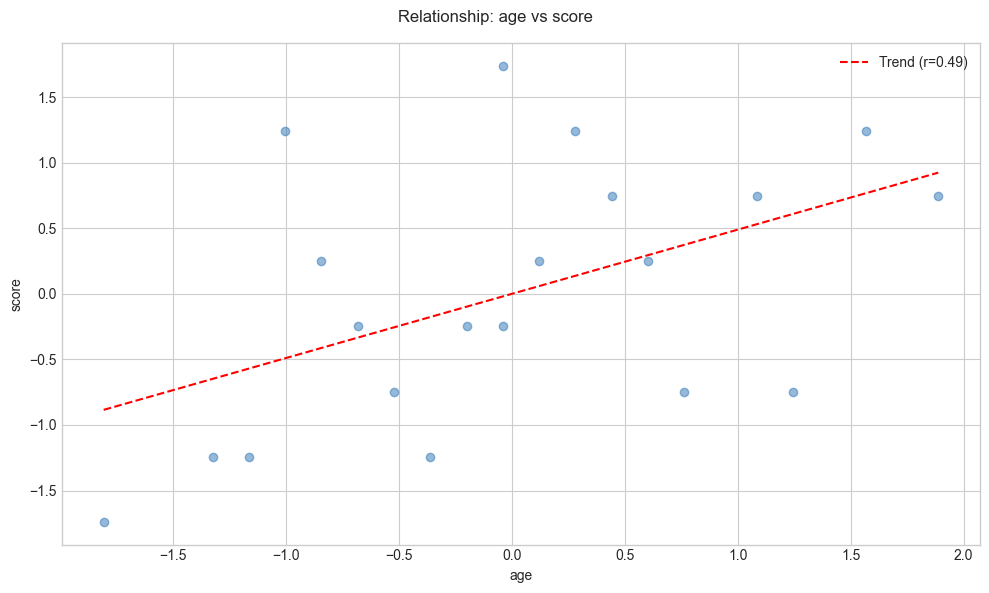

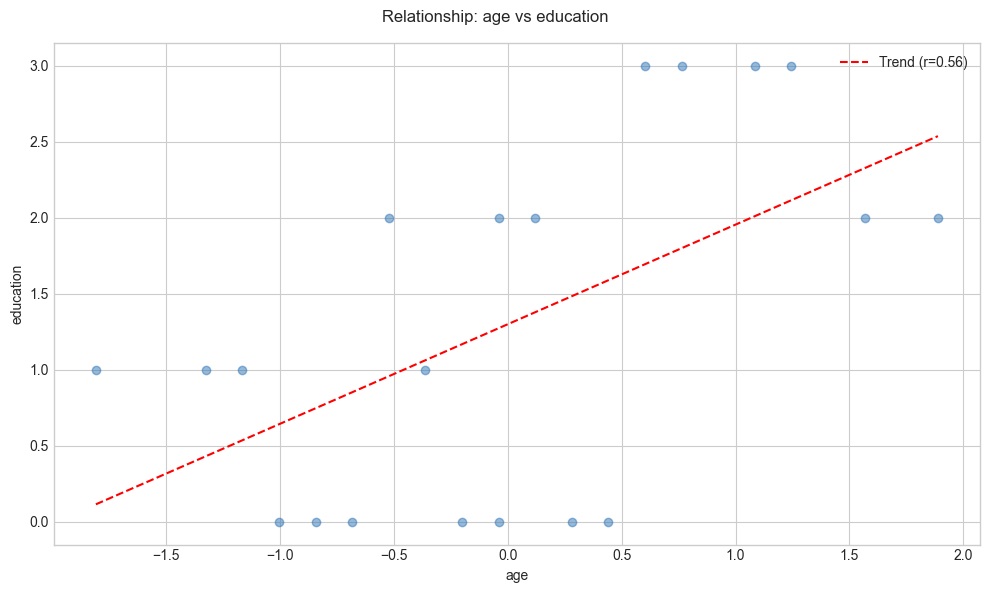

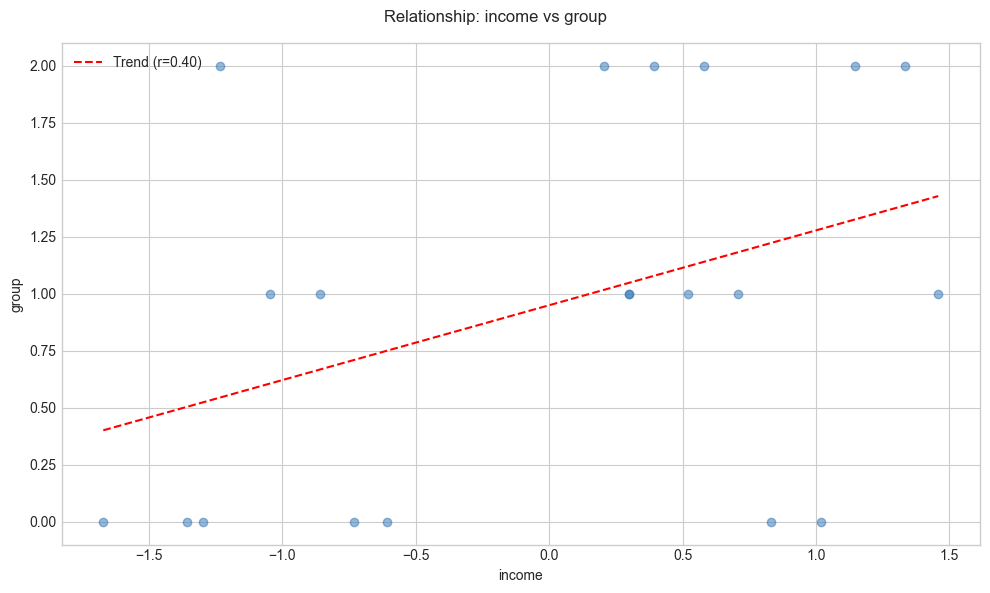

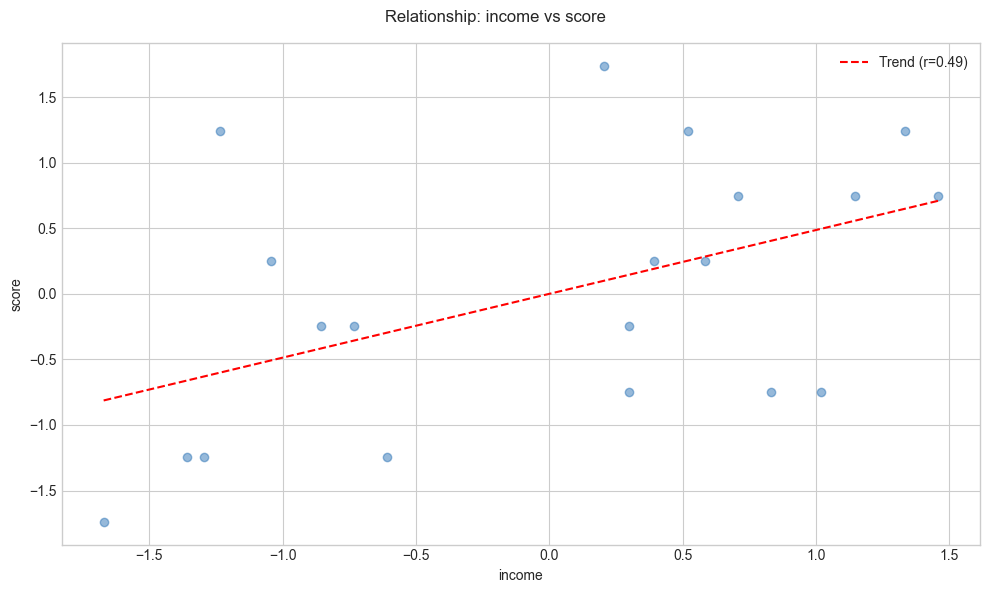

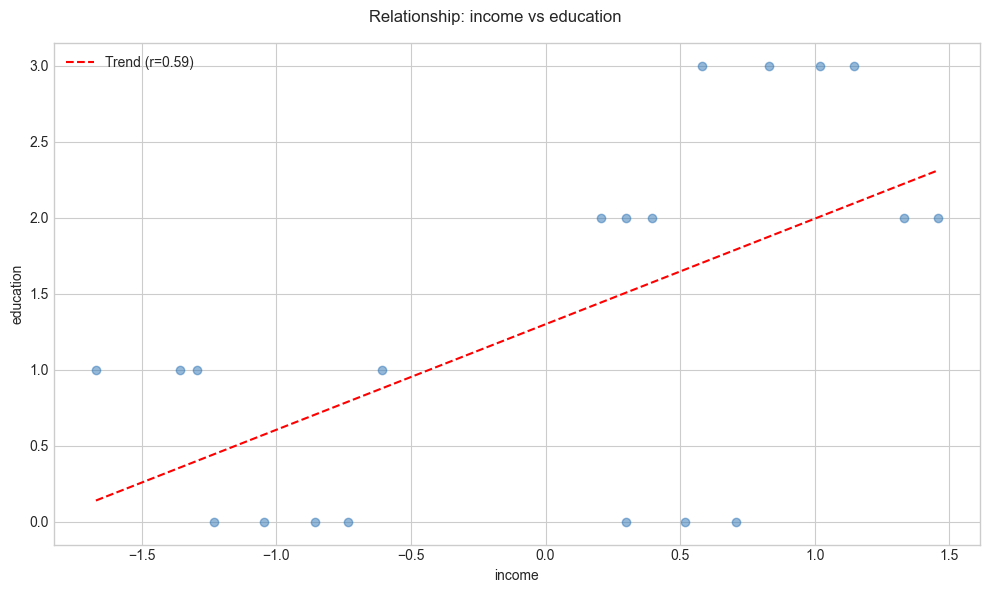

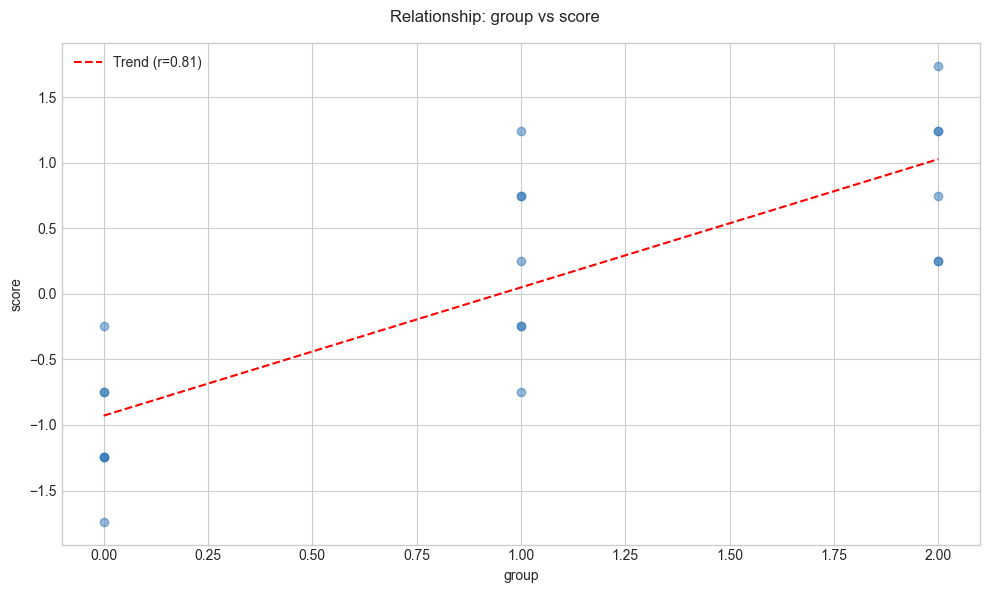

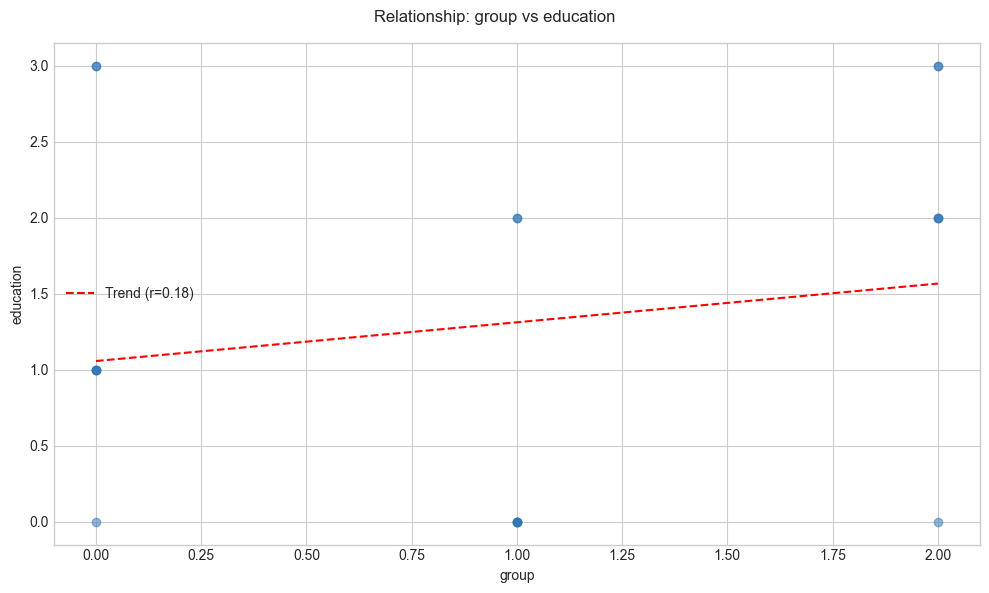

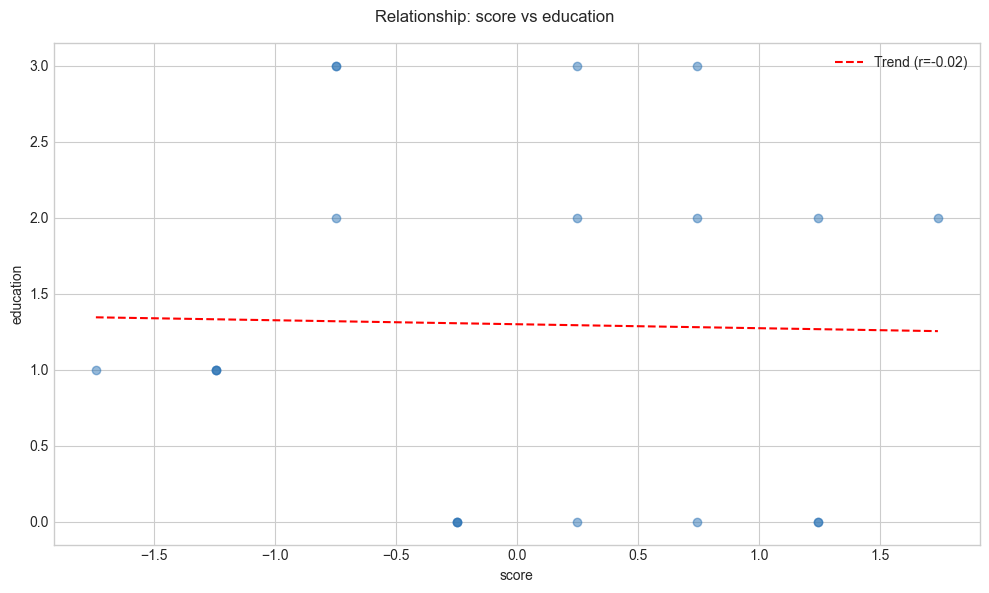

+--------------------------------------------------------------+
|  v  Run complete                                             |
|  Steps  : 7 completed, 0 failed                             |
|  Time   : 6.40s total                                        |
|  Output : outputs\06_data_preparation_demo\20260325_070000   |
+--------------------------------------------------------------+


0

In [3]:
from ds_engine.utils import pipeline_runner

config_path      = '../configs/06_data_prep.yml'
experiment_name  = '06_data_preparation_demo'

pipeline_runner.run(config_path, experiment_name)

## 4 — Inspect the JSON Report

All results are serialised to a timestamped JSON file. Let's load the most recent one.

In [4]:
import glob, json

# Find the most recently generated report
reports = sorted(
    glob.glob('../examples/outputs/06_data_preparation_demo/*/report.json'),
    reverse=True
)
latest = reports[0]
print('Report:', latest)

with open(latest) as f:
    report = json.load(f)

print('\nSteps recorded:', list(report['steps'].keys()))

Report: ../examples/outputs/06_data_preparation_demo\20260325_070000\report.json

Steps recorded: ['pre_flight_inspection', 'fill_missing_values', 'standardize_features', 'encode_group', 'encode_education', 'post_prep_summary', 'group_anova', 'relationships']


### 4a — Imputation Results

In [5]:
impute = report['steps']['fill_missing_values']
print('Method:', impute['method'])
print()
for col, info in impute['imputed_columns'].items():
    print(f"  {col:12s}  nulls filled: {info['null_count_fixed']}   fill value: {info['fill_value']}")

Method: median

  age           nulls filled: 1   fill value: 33.0
  income        nulls filled: 2   fill value: 76500.0


### 4b — Scaling Results

In [6]:
scale = report['steps']['standardize_features']
print('Method:', scale['method'])
print('Scaled columns:', scale['scaled_columns'])

Method: standard
Scaled columns: ['age', 'income', 'score']


### 4c — Encoding Results

In [7]:
for step_name in ['encode_group', 'encode_education']:
    enc = report['steps'][step_name]
    print(f"[{step_name}]")
    print(f"  Method : {enc['method']}")
    print(f"  Columns: {enc['encoded_columns']}")
    if enc.get('new_columns_added'):
        print(f"  New columns added: {enc['new_columns_added']}")
    print()

[encode_group]
  Method : label
  Columns: ['group']

[encode_education]
  Method : label
  Columns: ['education']



### 4d — ANOVA with Effect Size & Post-hoc Tukey HSD

The hypothesis step now automatically computes:
- **Eta-squared** (effect size) for every column tested
- **Tukey HSD post-hoc table** when the result is significant

In [8]:
anova = report['steps']['group_anova']

for col, result in anova.items():
    print(f"Column: {col}")
    print(f"  F-statistic : {result['statistic']:.4f}")
    print(f"  p-value     : {result['p_value']:.4f}")
    print(f"  Reject H0   : {result['reject_null']}")
    print(f"  {result['effect_name']}: {result['effect_size']:.4f}")
    if 'post_hoc_tukey' in result:
        print(f"  Tukey HSD Post-hoc:")
        tukey_df = pd.DataFrame(result['post_hoc_tukey'])
        print(tukey_df.to_string(index=False))
    print()

Column: age
  F-statistic : 0.9769
  p-value     : 0.3966
  Reject H0   : False
  Eta-squared: 0.1031

Column: income
  F-statistic : 1.8068
  p-value     : 0.1943
  Reject H0   : False
  Eta-squared: 0.1753

Column: score
  F-statistic : 17.6302
  p-value     : 0.0001
  Reject H0   : True
  Eta-squared: 0.6747
  Tukey HSD Post-hoc:
group1 group2  meandiff  p_adj   lower  upper  reject
     0      1    1.2773 0.0027  0.4505 2.1041    True
     0      2    1.9397 0.0001  1.0791 2.8002    True
     1      2    0.6623 0.1490 -0.1982 1.5229   False

Column: education
  F-statistic : 2.9625
  p-value     : 0.0787
  Reject H0   : False
  Eta-squared: 0.2585



### 4e — Relationship Analysis (Pearson Correlation + Effect Size)

In [9]:
rels = report['steps']['relationships']

rows = []
for pair, info in rels.items():
    rows.append({
        'pair'          : pair,
        'type'          : info['type'],
        'metric'        : info['metric'],
        'value'         : round(info['value'], 4),
        'p_value'       : round(info['p_value'], 4),
        'significant'   : info['is_significant'],
        'effect_size'   : info['effect_size'],
    })

pd.DataFrame(rows)

,pair,type,metric,value,p_value,significant,effect_size
0,age_vs_income,numeric-numeric,pearson,0.9424,0.0000,True,Strong
1,age_vs_group,numeric-numeric,pearson,0.3201,0.1688,False,Moderate
2,age_vs_score,numeric-numeric,pearson,0.4895,0.0285,True,Moderate
3,age_vs_education,numeric-numeric,pearson,0.5582,0.0105,True,Moderate
4,income_vs_group,numeric-numeric,pearson,0.3978,0.0824,False,Moderate
5,income_vs_score,numeric-numeric,pearson,0.4867,0.0295,True,Moderate
6,income_vs_education,numeric-numeric,pearson,0.5913,0.0060,True,Moderate
7,group_vs_score,numeric-numeric,pearson,0.8075,0.0000,True,Strong
8,group_vs_education,numeric-numeric,pearson,0.1792,0.4498,False,Weak
9,score_vs_education,numeric-numeric,pearson,-0.0223,0.9258,False,Weak


---

## Summary

This notebook showed a **full data preparation + statistics pipeline** declared entirely in YAML:

1. **Impute** — 2 missing values filled with column medians  
2. **Scale** — 3 numeric columns Z-score standardised  
3. **Encode** — 2 categorical columns label-encoded  
4. **ANOVA** — Eta² effect size + Tukey HSD post-hoc auto-computed when significant  
5. **Relationships** — Pearson correlations with qualitative effect-size labels  

> **Zero-Code philosophy**: the only Python written above is to *read and display results*.  
> The data science pipeline itself requires zero custom code.
